# Causal Forest multi-output — fit and predictive evaluation

This notebook trains per-endpoint causal forest models (an alternative to the T-learner in
`04_fit_calibrated_models.ipynb`) and evaluates how well the optimised model predicts the
actual events. For each endpoint it:

1. **fine-tunes** the hyper-parameters with Optuna (TPE);
2. trains a multi-output `CausalMultiOutputPipeline` on the full data and **saves** it to
   `models/CausalForest/`;
3. evaluates the optimised model with a **cross-validated ROC curve over the whole cohort**
   (out-of-fold) and a **confusion matrix on a held-out test set**.

Because a causal forest estimates the treatment *effect* θ(x) rather than an outcome
probability, the predicted **factual** risk is reconstructed from the DML identity
`P(Y=1 | x, T) = m(x) + (T − p_T)·θ(x)`, with `m(x)=E[Y|x]` the baseline outcome regression
and `p_T=P(T=1)` (≈0.5 by randomisation).

The CATE estimation and its visualisations live in `07_causal_forest_analysis.ipynb`.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna

from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from econml.dml import CausalForestDML
from lightgbm import LGBMRegressor, LGBMClassifier
from IPython.display import display

from thesis_utils import predict_proba_matrix, plot_confusion_matrices

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'data'))
MODELS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'models'))

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

`USE_KNN_IMPUTER` controls imputation strategy. `TUNE_CV` is the fold count for Optuna objective
estimation. `N_TRIALS` can be overridden from the environment (`CATE_N_TRIALS`).

In [2]:
USE_KNN_IMPUTER = True
KNN_NEIGHBORS = 5

TUNE_CV = 3                         # CV folds for the Optuna objective
N_TRIALS = int(os.environ.get('CATE_N_TRIALS', 15))   # Optuna trials

CALIBRATION_METHOD = 'sigmoid'      # Only for reference; CausalForest does not use it

print(f'Imputation strategy        : {"KNN" if USE_KNN_IMPUTER else "Median"}')
print(f'Optuna trials              : {N_TRIALS}')
print(f'CV folds for tuning        : {TUNE_CV}')

Imputation strategy        : KNN
Optuna trials              : 15
CV folds for tuning        : 3


## Load data and split by treatment arm

Load the cleaned features and 5 endpoints, drop leaky `fup_*` follow-up variables,
and encode treatment as 0 (abbreviated DAPT) / 1 (prolonged DAPT).

In [3]:
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y_df = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

TARGETS = [
    'cec_barc235_335d',
    'cec_cvdeath_335d',
    'cec_mi_335d',
    'cec_stroke_335d',
    'cec_bleed_335d',
]
TARGET_LABELS = ['barc_235', 'death', 'mi', 'stroke', 'bleed']
y_df = y_df[TARGETS]

LEAKY_COLS = ['fup_other', 'fup_nitrates', 'fup_insulin']
X_num = (X.drop(columns=LEAKY_COLS, errors='ignore')
           .select_dtypes(include=[np.number]))

regimen = X['regimen']
T = regimen.map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()

print(f'Samples: {len(X_num)}, Features: {X_num.shape[1]}')
print(f'Treatment: {np.sum(T)} prolonged DAPT, {len(T) - np.sum(T)} abbreviated DAPT')
print(f'Targets: {len(TARGETS)} endpoints')
print(f'Event rates: {dict(y_df.mean().round(3))}')

Samples: 4579, Features: 60
Treatment: 2284 prolonged DAPT, 2295 abbreviated DAPT
Targets: 5 endpoints
Event rates: {'cec_barc235_335d': np.float64(0.078), 'cec_cvdeath_335d': np.float64(0.018), 'cec_mi_335d': np.float64(0.024), 'cec_stroke_335d': np.float64(0.008), 'cec_bleed_335d': np.float64(0.111)}


## Custom Causal Multi-output Pipeline

Wrapper around per-endpoint CausalForestDML with robust imputation and preprocessing.
Trains one causal forest per target; `predict_cate` returns shape `(n_samples, n_targets)`.

In [4]:
from casual_multioutput_pipeline import CausalMultiOutputPipeline

## Hyper-parameter tuning with Optuna

TPE sampler searches the causal forest hyper-parameters to minimize the mean absolute CATE
prediction (lower variance = better calibrated effects) across endpoints, estimated via `TUNE_CV`-fold CV.

In [5]:
def make_objective(X, Y, T):
    def objective(trial):
        cf_params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 40),
            'max_samples': trial.suggest_float('max_samples', 0.2, 0.5),
            'inference': False,  # Set to True if you want to compute confidence intervals (slower)
        }
        pipeline = CausalMultiOutputPipeline(
            use_knn_imputer=USE_KNN_IMPUTER,
            knn_neighbors=KNN_NEIGHBORS,
            cf_params=cf_params
        )
        return pipeline.score_cv(X, Y, T, cv=TUNE_CV)
    return objective

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(make_objective(X_num.values, y_df.values, T), n_trials=N_TRIALS, show_progress_bar=True)
best_params = study.best_params
print(f'Best CV score: {study.best_value:.4f}')
print(f'Best params: {best_params}')

Best trial: 13. Best value: 0.00325629: 100%|██████████| 15/15 [09:51<00:00, 39.46s/it]

Best CV score: 0.0033
Best params: {'n_estimators': 750, 'max_depth': 4, 'min_samples_leaf': 40, 'max_samples': 0.20341031645086938}


## Fit final model and save

Train the optimized causal forest on the full dataset with inference enabled,
then save to `models_calibrated/CF/`.

In [6]:
best_params['n_estimators'] = best_params['n_estimators'] - best_params['n_estimators'] % 4

In [7]:
best_params['inference'] = True

final_pipeline = CausalMultiOutputPipeline(
    use_knn_imputer=USE_KNN_IMPUTER,
    knn_neighbors=KNN_NEIGHBORS,
    cf_params=best_params
)
final_pipeline.fit(X_num.values, y_df.values, T)

SAVE_DIR = os.path.join(MODELS_DIR, 'CausalForest')
os.makedirs(SAVE_DIR, exist_ok=True)

# Keep exactly one model: drop any stale file before saving
for stale in glob.glob(os.path.join(SAVE_DIR, 'CausalForest_*.joblib')):
    os.remove(stale)

fname = 'CausalForest_multioutput.joblib'
joblib.dump(final_pipeline, os.path.join(SAVE_DIR, fname))
print(f'Saved -> models/CausalForest/{fname}')
print('\nDone. Run 07_causal_forest_analysis.ipynb to analyse the effects.')

Saved -> models/CausalForest/CausalForest_multioutput.joblib

Done. Run 07_causal_forest_analysis.ipynb to analyse the effects.


## Estimate CATE on full cohort

Generate CATE predictions for all patients.

In [8]:
cate_preds = final_pipeline.predict_cate(X_num.values)
cate = pd.DataFrame(cate_preds, columns=TARGET_LABELS, index=X_num.index)

summary = pd.DataFrame({
    'mean_CATE': cate.mean(),
    'std_CATE': cate.std(),
    'pct_lDAPT_better': (cate < 0).mean() * 100,
    'pct_sDAPT_better': (cate > 0).mean() * 100,
})
print('CATE summary (Causal Forest)')
display(summary.round(4))

CATE summary (Causal Forest)


,mean_CATE,std_CATE,pct_lDAPT_better,pct_sDAPT_better
barc_235,0.028,0.004,0.000,100.000
death,0.003,0.004,6.574,93.427
mi,-0.003,0.003,82.769,17.231
stroke,0.004,0.004,3.603,96.397
bleed,0.048,0.005,0.000,100.000


## Visualizations

### CATE distributions per target

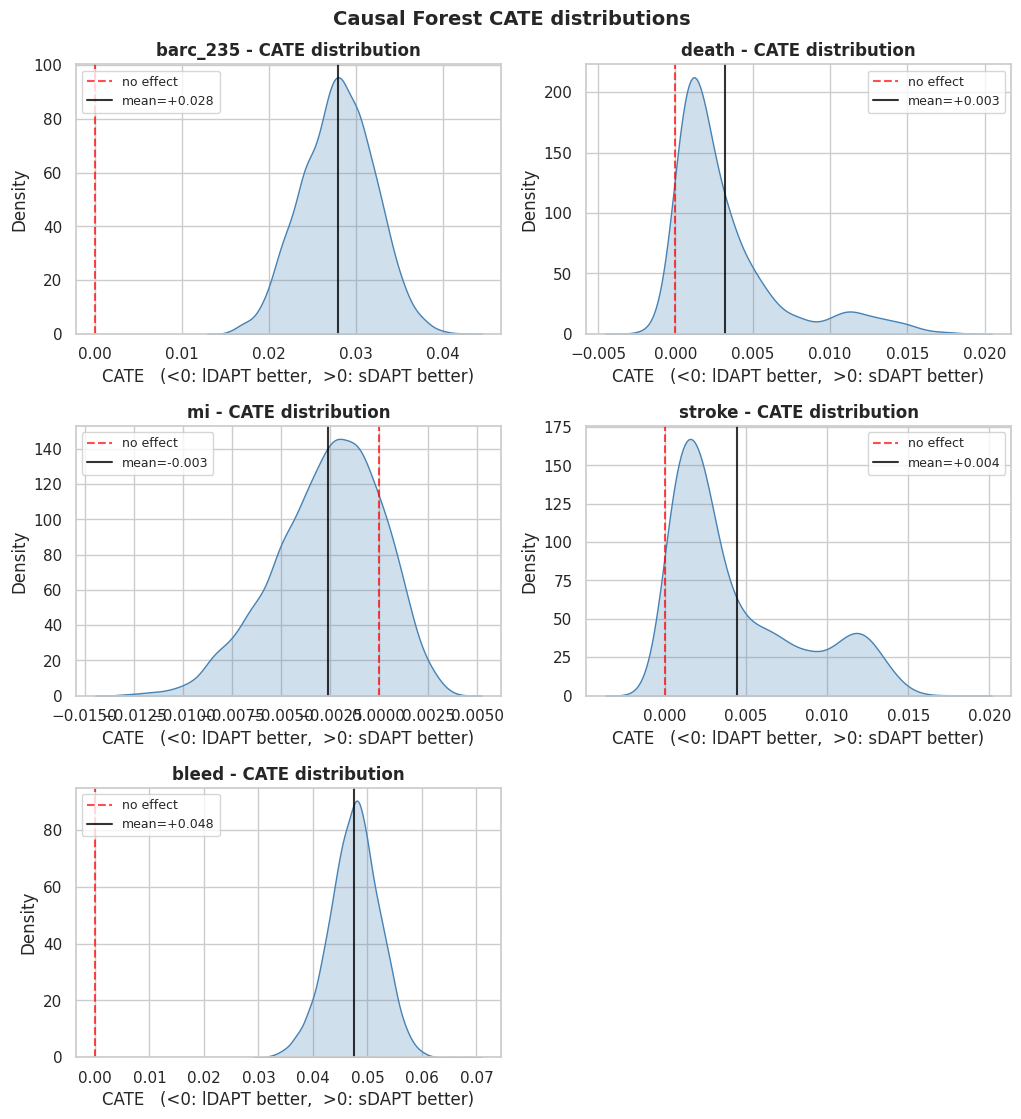

In [9]:
def target_grid(ncols=2, figsize_per=(5.2, 3.8)):
    n = len(TARGET_LABELS)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows), squeeze=False)
    axes = axes.ravel()
    for ax in axes[n:]:
        ax.set_visible(False)
    return fig, axes

fig, axes = target_grid(ncols=2)
for ax, label in zip(axes, TARGET_LABELS):
    sns.kdeplot(cate[label], ax=ax, fill=True, color='steelblue')
    ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='no effect')
    ax.axvline(cate[label].mean(), color='black', linestyle='-', alpha=0.8,
               label=f'mean={cate[label].mean():+.3f}')
    ax.set_title(f'{label} - CATE distribution', fontweight='bold')
    ax.set_xlabel('CATE   (<0: lDAPT better,  >0: sDAPT better)')
    ax.legend(fontsize=9)
fig.suptitle('Causal Forest CATE distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Sorted CATE (uplift curves)

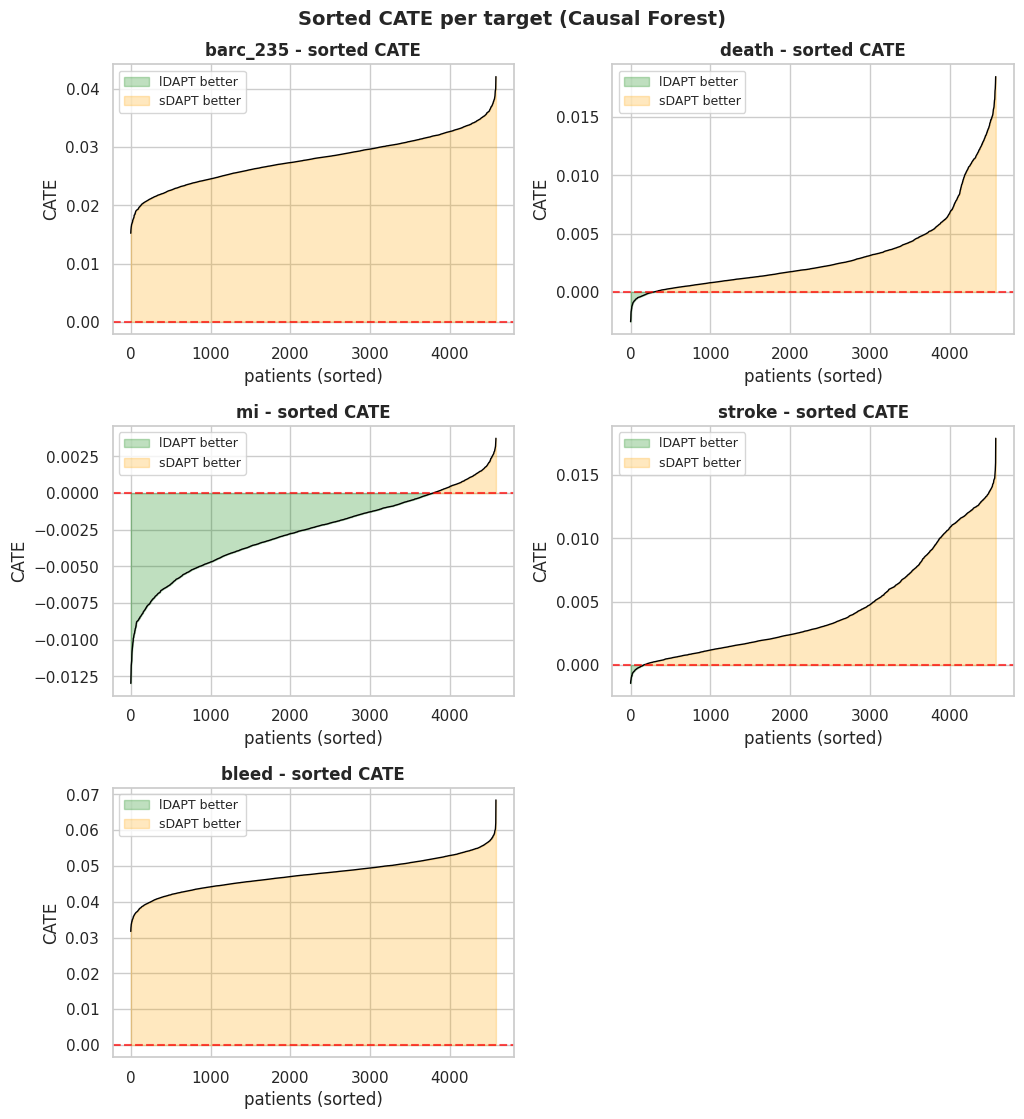

In [10]:
fig, axes = target_grid(ncols=2)
for ax, label in zip(axes, TARGET_LABELS):
    ordered = np.sort(cate[label].to_numpy())
    xs = np.arange(len(ordered))
    ax.plot(xs, ordered, linewidth=1.0, color='black')
    ax.axhline(0, color='red', linestyle='--', alpha=0.7)
    ax.fill_between(xs, ordered, 0, where=ordered < 0, color='green', alpha=0.25, label='lDAPT better')
    ax.fill_between(xs, ordered, 0, where=ordered > 0, color='orange', alpha=0.25, label='sDAPT better')
    ax.set_title(f'{label} - sorted CATE', fontweight='bold')
    ax.set_xlabel('patients (sorted)')
    ax.set_ylabel('CATE')
    ax.legend(fontsize=9, loc='upper left')
fig.suptitle('Sorted CATE per target (Causal Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Causal feature importance

Mean feature importance across all endpoints.

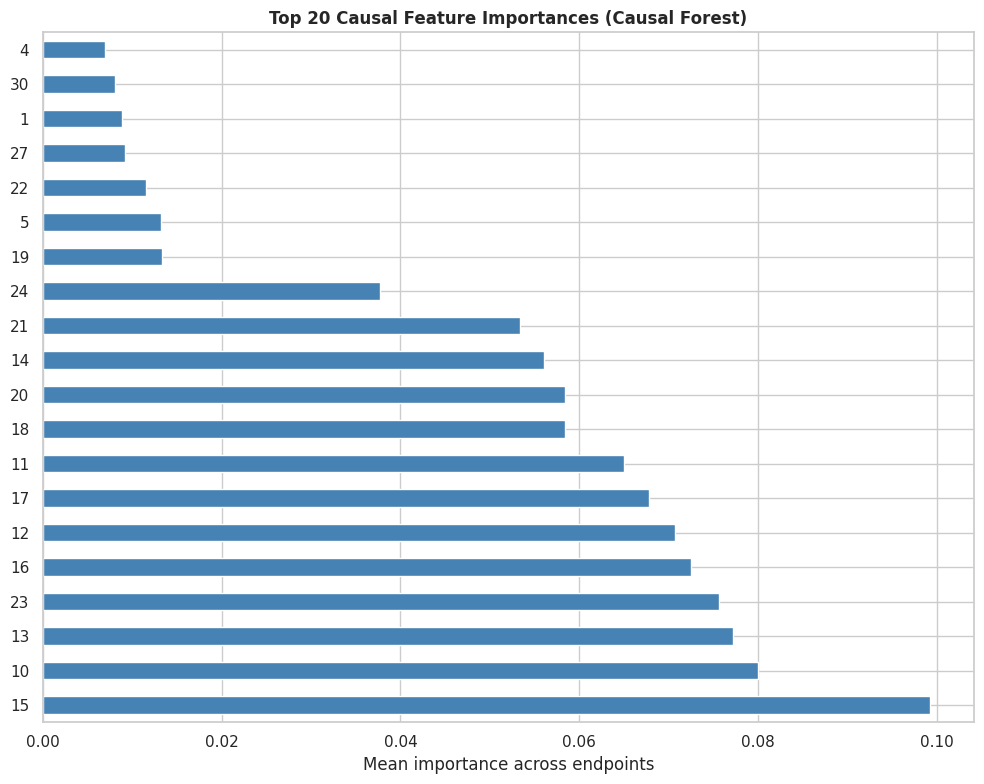

In [11]:
feat_importances = pd.Series(
    final_pipeline.get_feature_importances(),
    index=final_pipeline.feature_names if final_pipeline.feature_names else [f'F_{i}' for i in range(X_num.shape[1])]
)

fig, ax = plt.subplots(figsize=(10, 8))
feat_importances.nlargest(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Causal Feature Importances (Causal Forest)', fontweight='bold')
ax.set_xlabel('Mean importance across endpoints')
plt.tight_layout()
plt.show()